In [31]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image, ImageOps
from collections import Counter

In [32]:
data_path = Path("D:/bip/data")

In [33]:
df = pd.read_csv(r"D:\bip\data\birch_trees_bratislava.csv", encoding='cp1250', sep=';')

In [34]:
df.head()

,ID,N (°),E (°),circumference (cm),vitality (5 - highest),fungal infection (3 - worst)
0,1,48.135122,17.214558,34.0,4.0,3
1,2,48.134505,17.214642,65.0,1.0,3
2,3,48.167051,17.170838,141.0,1.0,3
3,4,48.166559,17.171152,77.0,3.0,3
4,5,48.166573,17.171204,82.0,2.0,3


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            98 non-null     int64  
 1   N (°)                         98 non-null     float64
 2   E (°)                         98 non-null     float64
 3   circumference (cm)            98 non-null     float64
 4   vitality (5 - highest)        98 non-null     float64
 5   fungal infection (3 - worst)  98 non-null     int64  
dtypes: float64(4), int64(2)
memory usage: 4.7 KB


In [36]:
df.describe().round(2)

,ID,N (°),E (°),circumference (cm),vitality (5 - highest),fungal infection (3 - worst)
count,98.00,98.00,98.00,98.00,98.00,98.00
mean,49.50,48.18,17.13,94.08,3.45,1.76
std,28.43,0.07,0.09,34.70,1.11,1.10
min,1.00,48.11,17.02,20.00,1.00,0.00
25%,25.25,48.14,17.06,77.00,3.00,1.00
50%,49.50,48.15,17.12,92.00,3.75,2.00
75%,73.75,48.20,17.17,115.75,4.00,3.00
max,98.00,48.47,17.46,180.00,5.00,3.00


In [37]:
df.columns

Index(['ID', 'N (°)', 'E (°)', 'circumference (cm)', 'vitality (5 - highest)',
       'fungal infection (3 - worst)'],
      dtype='str')

In [38]:
df.rename(
    columns={
        "circumference (cm)": "circumference_cm", 
        "vitality (5 - highest)": "vitality", 
        "fungal infection (3 - worst)": "fungal_infection"
        }, 
    inplace=True
    )

In [39]:
df.columns

Index(['ID', 'N (°)', 'E (°)', 'circumference_cm', 'vitality',
       'fungal_infection'],
      dtype='str')

In [40]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
ID                  0
N (°)               0
E (°)               0
circumference_cm    0
vitality            0
fungal_infection    0
dtype: int64


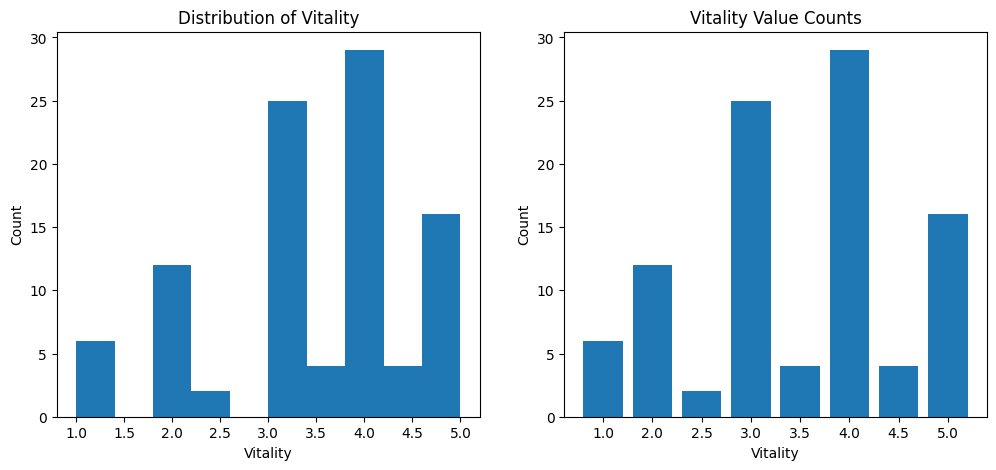

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df["vitality"])
axes[0].set_xlabel("Vitality")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Vitality")

vc = df["vitality"].value_counts().sort_index()
axes[1].bar(vc.index.astype(str), vc.values)
axes[1].set_xlabel("Vitality")
axes[1].set_ylabel("Count")
axes[1].set_title("Vitality Value Counts")
plt.show()

In [42]:
vitality_groups = df.groupby("vitality")["circumference_cm"].agg(list)

C:\Users\user\AppData\Local\Temp\ipykernel_4652\2309671659.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(vitality_groups.values, labels=vitality_groups.index.astype(str))


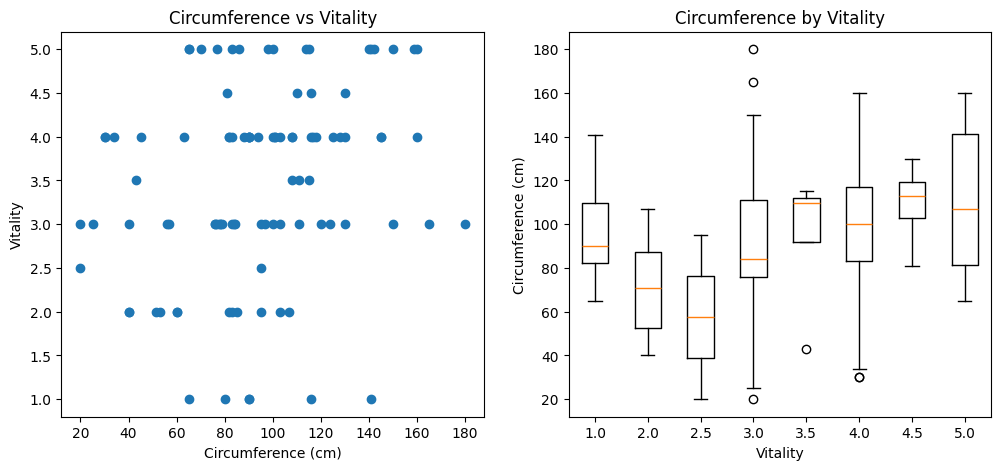

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df["circumference_cm"], df["vitality"])
axes[0].set_xlabel("Circumference (cm)")
axes[0].set_ylabel("Vitality")
axes[0].set_title("Circumference vs Vitality")

axes[1].boxplot(vitality_groups.values, labels=vitality_groups.index.astype(str))
axes[1].set_xlabel("Vitality")
axes[1].set_ylabel("Circumference (cm)")
axes[1].set_title("Circumference by Vitality")

plt.show()

In [44]:
print(f"Pearson correlation: {df['circumference_cm'].corr(df['vitality'], method='pearson'):.2f}")
print(f"Spearman correlation: {df['circumference_cm'].corr(df['vitality'], method='spearman'):.2f}")

Pearson correlation: 0.25
Spearman correlation: 0.28


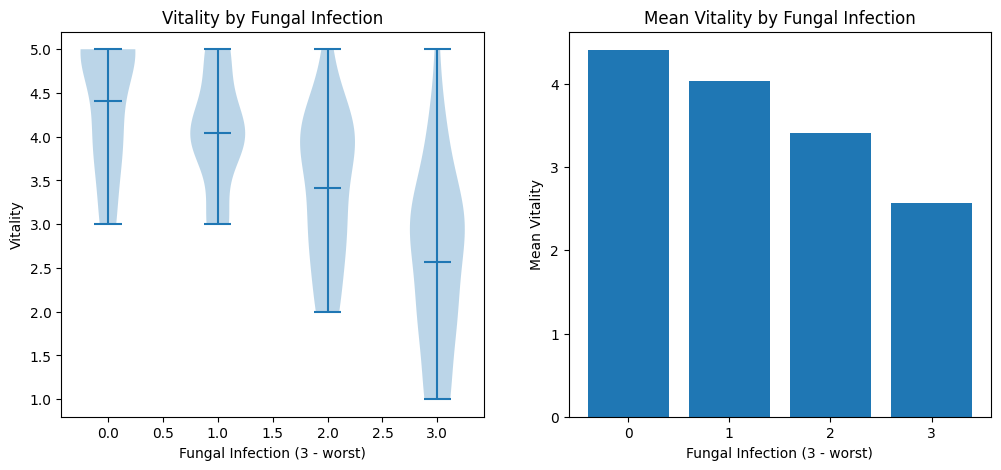

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fungal_groups = [df[df["fungal_infection"] == i]["vitality"].values
                          for i in sorted(df["fungal_infection"].unique())]
axes[0].violinplot(fungal_groups, showmeans=True, positions=sorted(df["fungal_infection"].unique()))
axes[0].set_xlabel("Fungal Infection (3 - worst)")
axes[0].set_ylabel("Vitality")
axes[0].set_title("Vitality by Fungal Infection")

mean_vitality_by_fungal = df.groupby("fungal_infection")["vitality"].mean()
axes[1].bar(mean_vitality_by_fungal.index.astype(str), mean_vitality_by_fungal.values)
axes[1].set_xlabel("Fungal Infection (3 - worst)")
axes[1].set_ylabel("Mean Vitality")
axes[1].set_title("Mean Vitality by Fungal Infection")
plt.show()

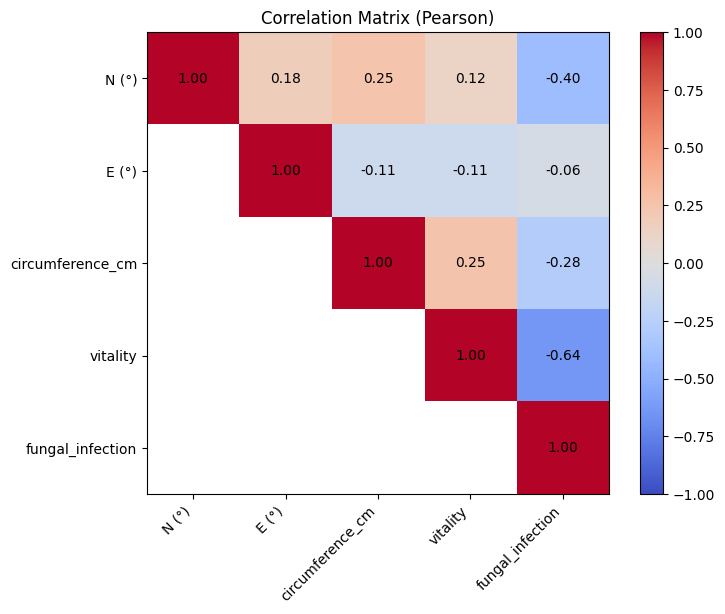

In [46]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop("ID")
corr_matrix = df[numeric_cols].corr(method='pearson')

# --- add this ---
mask = np.tril(np.ones_like(corr_matrix, dtype=bool), k=-1)
masked_corr = corr_matrix.where(~mask)
# ----------------

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(masked_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(np.arange(len(numeric_cols)))
ax.set_yticks(np.arange(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        if not mask[i, j]:   # --- add this check ---
            text = ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                           ha="center", va="center", color="black")
ax.set_title("Correlation Matrix (Pearson)")
plt.show()

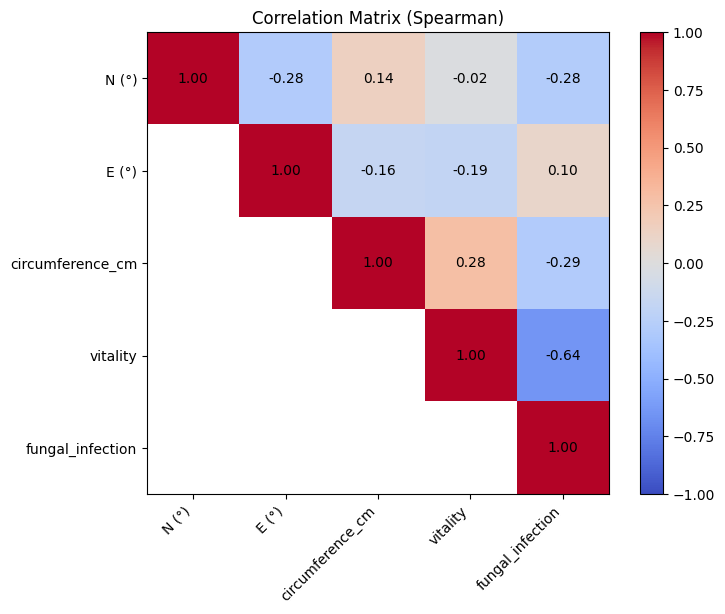

In [47]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop("ID")
corr_matrix = df[numeric_cols].corr(method='spearman')

# --- add this ---
mask = np.tril(np.ones_like(corr_matrix, dtype=bool), k=-1)
masked_corr = corr_matrix.where(~mask)
# ----------------

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(masked_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(np.arange(len(numeric_cols)))
ax.set_yticks(np.arange(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        if not mask[i, j]:   # --- add this check ---
            text = ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                           ha="center", va="center", color="black")
ax.set_title("Correlation Matrix (Spearman)")
plt.show()

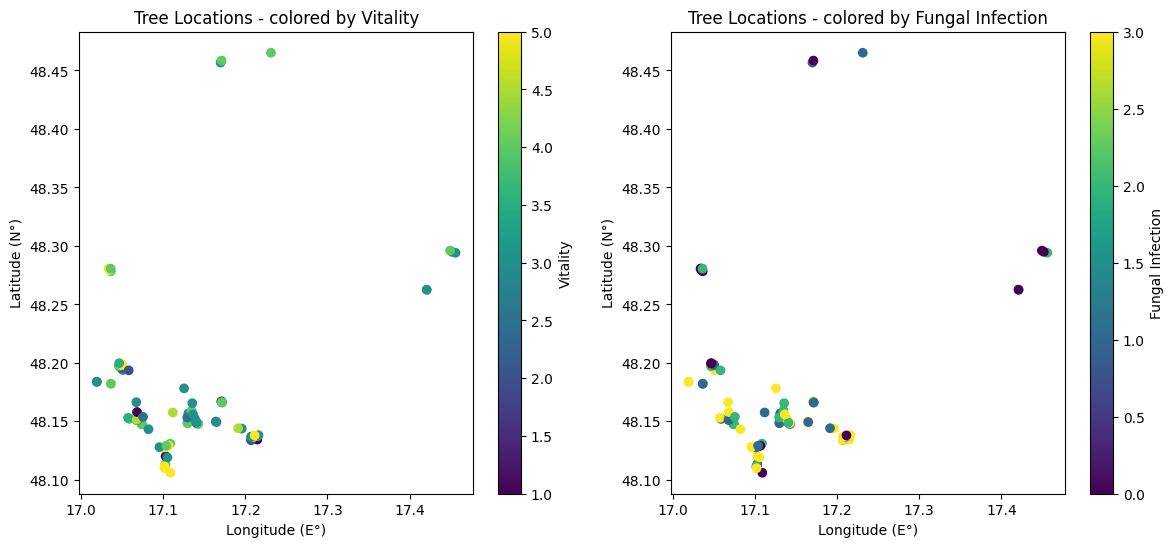

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc1 = axes[0].scatter(df['E (°)'], df['N (°)'],
                       c=df['vitality'])
plt.colorbar(sc1, ax=axes[0], label='Vitality')
axes[0].set_xlabel('Longitude (E°)')
axes[0].set_ylabel('Latitude (N°)')
axes[0].set_title('Tree Locations - colored by Vitality')

# Scatter colored by fungal infection
sc2 = axes[1].scatter(df['E (°)'], df['N (°)'],
                       c=df['fungal_infection'])
plt.colorbar(sc2, ax=axes[1], label='Fungal Infection')
axes[1].set_xlabel('Longitude (E°)')
axes[1].set_ylabel('Latitude (N°)')
axes[1].set_title('Tree Locations - colored by Fungal Infection')

plt.show()

In [49]:
image_counts, missing_trees = dict(), list()

for tree_id in df["ID"]:
    tree_folder = data_path / str(tree_id)
    if tree_folder.exists():
        imgs = list(tree_folder.glob("*.jpg"))
        image_counts[tree_id] = len(imgs)
    else:
        image_counts[tree_id] = 0
        missing_trees.append(tree_id)

df["image_count"] = df["ID"].map(image_counts)

print(f'Trees with images:    {(df["image_count"] > 0).sum()}')
print(f'Trees WITHOUT images: {len(missing_trees)} -> IDs: {missing_trees}')
print(f'\nImage count stats:')
print(df['image_count'].describe().round(1))

Trees with images:    80
Trees WITHOUT images: 18 -> IDs: [15, 16, 26, 63, 64, 71, 81, 82, 83, 84, 85, 86, 87, 88, 92, 96, 97, 98]

Image count stats:
count    98.0
mean      4.7
std       3.0
min       0.0
25%       3.0
50%       5.0
75%       6.0
max      12.0
Name: image_count, dtype: float64


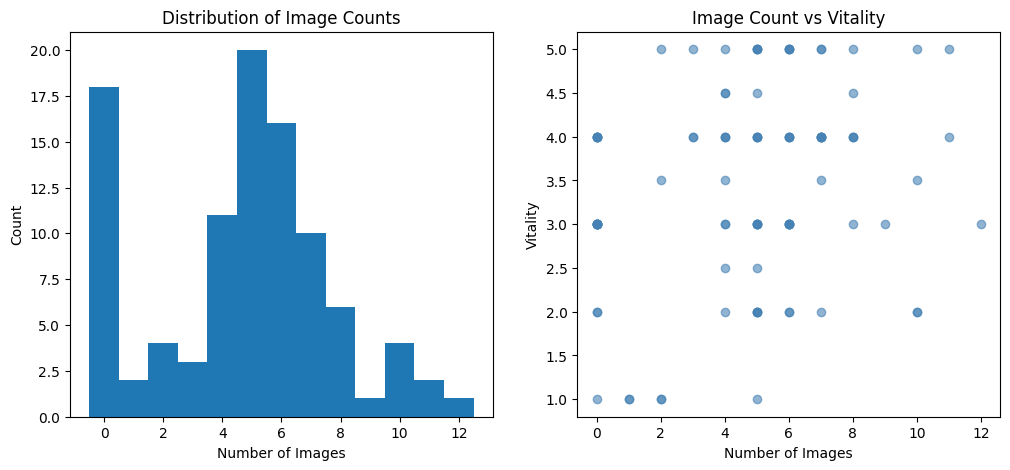

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["image_count"], bins=range(0, df["image_count"].max() + 2), align='left')
axes[0].set_xlabel("Number of Images")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Image Counts")

# scatter instead of boxplot
axes[1].scatter(df["image_count"], df["vitality"], alpha=0.6, color="steelblue")
axes[1].set_xlabel("Number of Images")
axes[1].set_ylabel("Vitality")
axes[1].set_title("Image Count vs Vitality")

plt.show()

In [51]:
def show_tree_samples(df, image_dir, n_per_level=2, max_imgs=3):
    vitality_levels = sorted(df["vitality"].unique())
    fig, axes = plt.subplots(
        len(vitality_levels), 
        n_per_level * max_imgs, 
        figsize=(
            n_per_level*max_imgs*2.5, 
            len(vitality_levels)*2.5
            )
        )
    for row_idx, level in enumerate(vitality_levels):
        trees = df[df["vitality"] == level]["ID"].tolist()
        sampled_trees = trees[:n_per_level]
        col_idx = 0
        for tree_id in sampled_trees:
            tree_folder = image_dir / str(tree_id)
            img = sorted(tree_folder.glob("*.jpg"))[:max_imgs] if tree_folder.exists() else []
            for img_path in img:
                ax = axes[row_idx, col_idx] if len(vitality_levels) > 1 else axes[col_idx]
                img = ImageOps.exif_transpose(Image.open(img_path)).resize((200, 200))
                ax.imshow(img)
                ax.axis('off')
                ax.set_title(f"ID: {tree_id} \n Vitality: {level}")
                col_idx += 1
            while col_idx < (sampled_trees.index(tree_id) + 1) * max_imgs:
                ax = axes[row_idx, col_idx] if len(vitality_levels) > 1 else axes[col_idx]
                ax.axis('off')
                col_idx += 1
        axes[row_idx][0].set_ylabel(f"Vitality {level}", fontsize=12)
    plt.suptitle("Sample Tree Images by Vitality Level", fontsize=16)
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

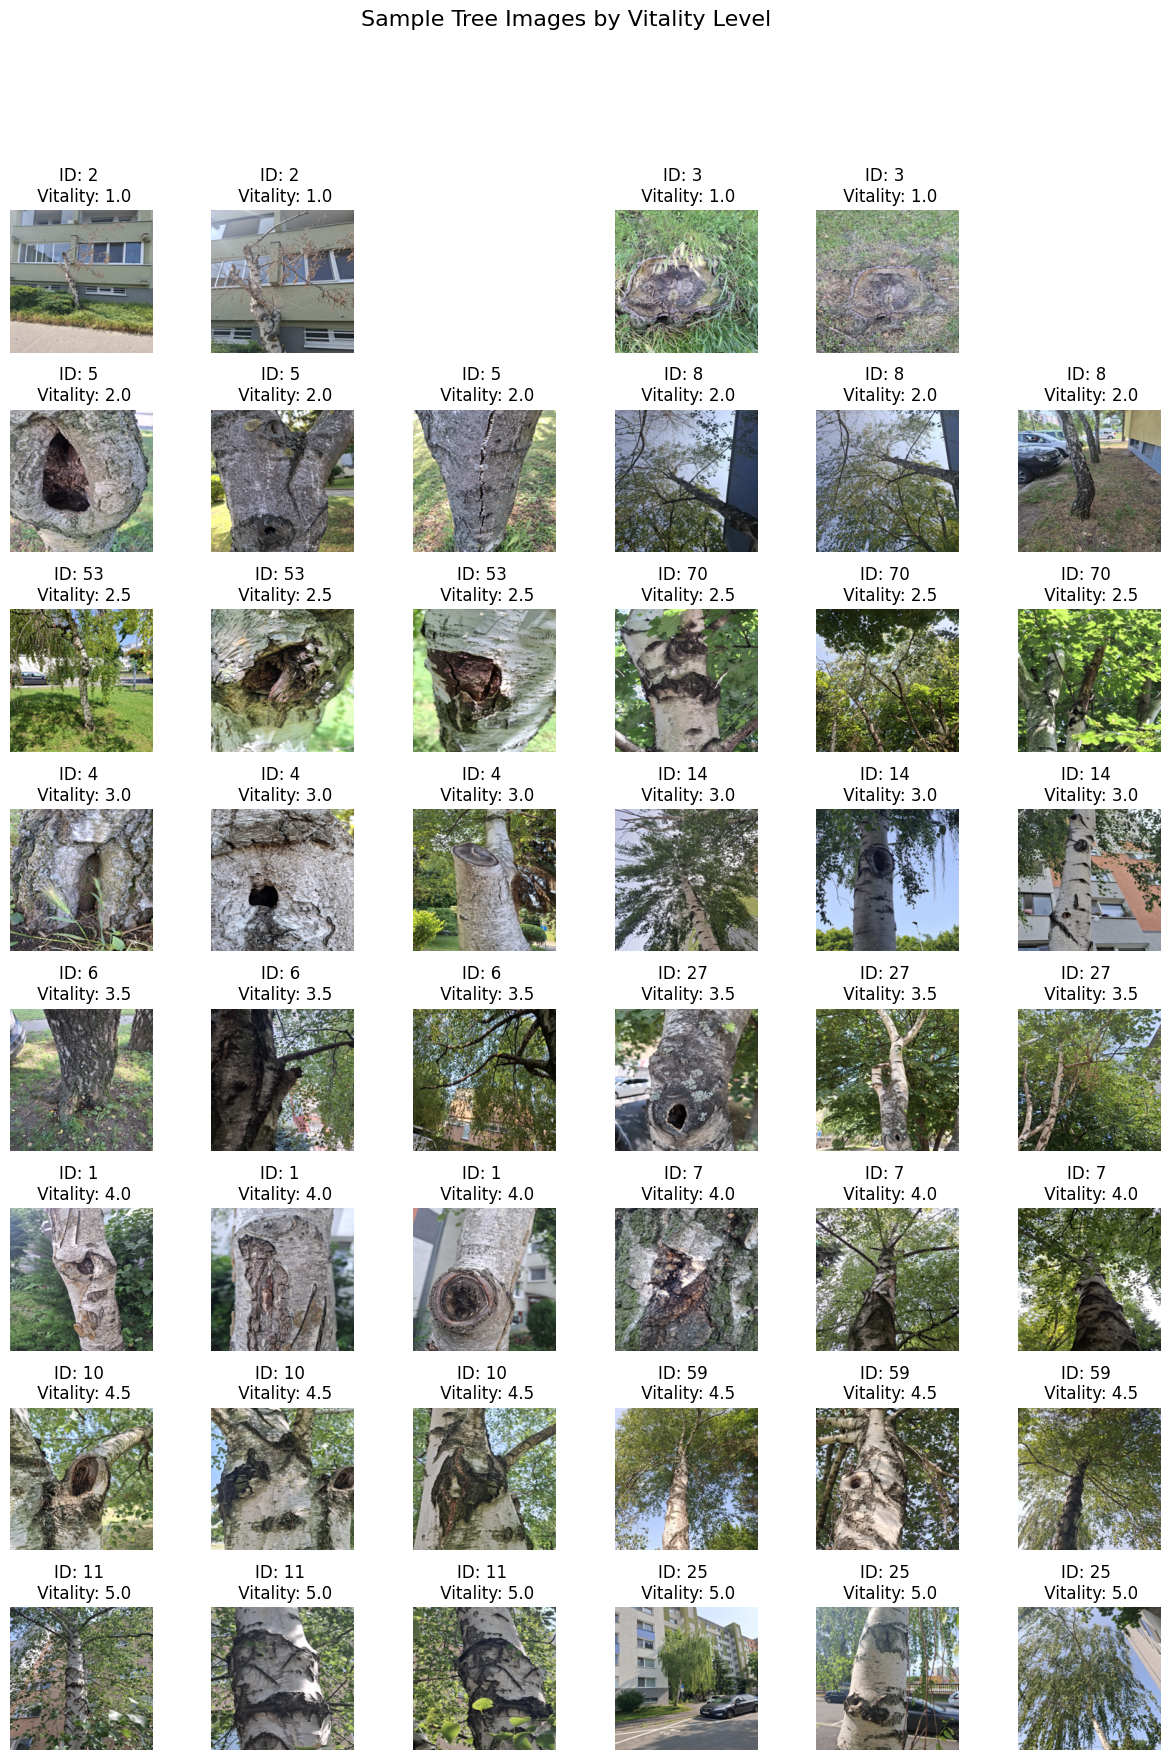

In [52]:
show_tree_samples(df, data_path, n_per_level=2, max_imgs=3)

In [53]:
sizes = list()
for tree_id in df["ID"]:
    folder = data_path / str(tree_id)
    if folder.exists():
        for imag_path in list(folder.glob("*.jpg"))[:1]:
            with Image.open(imag_path) as img:
                sizes.append(img.size)

In [54]:
unique_sizes = Counter(sizes)
print(f"Unique image sizes and their counts: {unique_sizes}")
print("Top 10 most common sizes:")
for size, count in unique_sizes.most_common(10):
    print(f"{size[0]}x{size[1]}: {count} images")

Unique image sizes and their counts: Counter({(4080, 3060): 80})
Top 10 most common sizes:
4080x3060: 80 images


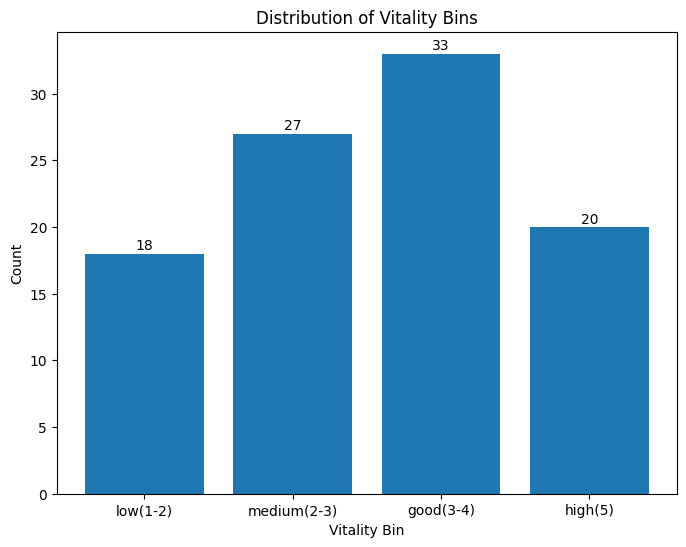

In [55]:
df["vitality_bin"] = pd.cut(df["vitality"],
                            bins = [0, 2, 3, 4, 5],
                            labels=["low(1-2)", "medium(2-3)", "good(3-4)", "high(5)"])
fig, ax = plt.subplots(figsize=(8, 6))
vc = df["vitality_bin"].value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values)
ax.set_xlabel("Vitality Bin")
ax.set_ylabel("Count")
ax.set_title("Distribution of Vitality Bins")
for i, v in  enumerate(vc.values):
    ax.text(i, v + 0.3, str(v), ha='center')
plt.show()